**Секція 1. Логістична регресія з нуля.**

Будемо крок за кроком будувати модель лог регресії з нуля для передбачення, чи буде врожай більше за 80 яблук (задача подібна до лекційної, але на класифікацію).

Давайте нагадаємо основні формули для логістичної регресії.

### Функція гіпотези - обчислення передбачення у логістичній регресії:

$$
\hat{y} = \sigma(x W^T + b) = \frac{1}{1 + e^{-(x W^T + b)}}
$$

Де:
- $ \hat{y} $ — це ймовірність "позитивного" класу.
- $ x $ — це вектор (або матриця для набору прикладів) вхідних даних.
- $ W $ — це вектор (або матриця) вагових коефіцієнтів моделі.
- $ b $ — це зміщення (bias).
- $ \sigma(z) $ — це сигмоїдна функція активації.

### Як обчислюється сигмоїдна функція:

Сигмоїдна функція $ \sigma(z) $ має вигляд:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Ця функція перетворює будь-яке дійсне значення $ z $ в інтервал від 0 до 1, що дозволяє інтерпретувати вихід як ймовірність для логістичної регресії.

### Формула функції втрат для логістичної регресії (бінарна крос-ентропія):

Функція втрат крос-ентропії оцінює, наскільки добре модель передбачає класи, порівнюючи передбачені ймовірності $ \hat{y} $ із справжніми мітками $ y $. Формула наступна:

$$
L(y, \hat{y}) = - \left[ y \cdot \log(\hat{y}) + (1 - y) \cdot \log(1 - \hat{y}) \right]
$$

Де:
- $ y $ — це справжнє значення (мітка класу, 0 або 1).
- $ \hat{y} $ — це передбачене значення (ймовірність).



1.
Тут вже наведений код для ініціювання набору даних в форматі numpy. Перетворіть `inputs`, `targets` на `torch` тензори. Виведіть результат на екран.

In [18]:
import torch
import numpy as np

In [19]:
# Вхідні дані (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]], dtype='float32')

# Таргети (apples > 80)
targets = np.array([[0],
                    [1],
                    [1],
                    [0],
                    [1]], dtype='float32')

In [20]:
# 1. Перетворюємо numpy → torch tensors
inputs = torch.from_numpy(inputs)      # форма (5, 3)
targets = torch.from_numpy(targets)    # форма (5, 1)

print("Inputs (тензор):")
print(inputs)

print("\nTargets (тензор):")
print(targets)

Inputs (тензор):
tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [ 87., 134.,  58.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.]])

Targets (тензор):
tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.]])


2. Ініціюйте ваги `w`, `b` для моделі логістичної регресії потрібної форми зважаючи на розмірності даних випадковими значеннями з нормального розподілу. Лишаю тут код для фіксації `random_seed`.

In [21]:
torch.random.manual_seed(1)

In [22]:
torch.random.manual_seed(1)

# 2. Ініціалізація вагів і зміщення з нормального розподілу
w = torch.randn(3, 1, requires_grad=True)   # 3 фічі → 1 вихід
b = torch.randn(1, requires_grad=True)      # зміщення (bias)

print("w shape:", w.shape)
print("w:", w)

print("\nb shape:", b.shape)
print("b:", b)

w shape: torch.Size([3, 1])
w: tensor([[0.6614],
        [0.2669],
        [0.0617]], requires_grad=True)

b shape: torch.Size([1])
b: tensor([0.6213], requires_grad=True)


3. Напишіть функцію `model`, яка буде обчислювати функцію гіпотези в логістичній регресії і дозволяти робити передбачення на основі введеного рядка даних і коефіцієнтів в змінних `w`, `b`.

  **Важливий момент**, що функція `model` робить обчислення на `torch.tensors`, тож для математичних обчислень використовуємо фукнціонал `torch`, наприклад:
  - обчсилення $e^x$: `torch.exp(x)`
  - обчсилення $log(x)$: `torch.log(x)`
  - обчислення середнього значення вектору `x`: `torch.mean(x)`

  Використайте функцію `model` для обчислення передбачень з поточними значеннями `w`, `b`.Виведіть результат обчислень на екран.

  Проаналізуйте передбачення. Чи не викликають вони у вас підозр? І якщо викликають, то чим це може бути зумовлено?

In [23]:
# 3. Функція моделі логістичної регресії
def model(x):
    # Обчислюємо лінійну комбінацію ознак
    z = x @ w + b   # @ = матричне множення
    # Сигмоїдна активація
    y_pred = 1 / (1 + torch.exp(-z))
    return y_pred

# Обчислення передбачень на основі поточних w і b
preds = model(inputs)
print("Передбачені ймовірності (ŷ):")
print(preds)

Передбачені ймовірності (ŷ):
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]], grad_fn=<MulBackward0>)


4. Напишіть функцію `binary_cross_entropy`, яка приймає на вхід передбачення моделі `predicted_probs` та справжні мітки в даних `true_labels` і обчислює значення втрат (loss)  за формулою бінарної крос-ентропії для кожного екземпляра та вертає середні втрати по всьому набору даних.
  Використайте функцію `binary_cross_entropy` для обчислення втрат для поточних передбачень моделі.

In [24]:
# 4. Функція обчислення втрат — бінарна крос-ентропія
def binary_cross_entropy(predicted_probs, true_labels):
    # Щоб уникнути log(0)
    eps = 1e-7
    predicted_probs = torch.clamp(predicted_probs, eps, 1 - eps)

    # Формула втрат
    loss = -(true_labels * torch.log(predicted_probs) +
             (1 - true_labels) * torch.log(1 - predicted_probs))

    # Повертаємо середнє значення по всіх прикладах
    return torch.mean(loss)

# Використай функцію на своїх поточних передбаченнях
predicted_probs = model(inputs)
loss = binary_cross_entropy(predicted_probs, targets)

print("Втрати (loss):", loss.item())

Втрати (loss): 6.376954078674316


5. Зробіть зворотнє поширення помилки і виведіть градієнти за параметрами `w`, `b`. Проаналізуйте їх значення. Як гадаєте, чому вони саме такі?

In [25]:
# 5. Зворотне поширення помилки
loss.backward()

print("Градієнти w:")
print(w.grad)

print("\nГрадієнт b:")
print(b.grad)

Градієнти w:
tensor([[0.],
        [0.],
        [0.]])

Градієнт b:
tensor([0.])


**Що сталось?**

В цій задачі, коли ми ініціювали значення випадковими значеннями з нормального розподілу, насправді ці значення не були дуже гарними стартовими значеннями і привели до того, що градієнти стали дуже малими або навіть рівними нулю (це призводить до того, що градієнти "зникають"), і відповідно при оновленні ваг у нас не буде нічого змінюватись. Це називається `gradient vanishing`. Це відбувається через **насичення сигмоїдної функції активації.**

У нашій задачі ми використовуємо сигмоїдну функцію активації, яка має такий вигляд:

   $$
   \sigma(z) = \frac{1}{1 + e^{-z}}
   $$


Коли значення $z$ дуже велике або дуже мале, сигмоїдна функція починає "насичуватись". Це означає, що для великих позитивних $z$ сигмоїда наближається до 1, а для великих негативних — до 0. В цих діапазонах градієнти починають стрімко зменшуватись і наближаються до нуля (бо градієнт - це похідна, похідна на проміжку функції, де вона паралельна осі ОХ, дорівнює 0), що робить оновлення ваг неможливим.

![](https://editor.analyticsvidhya.com/uploads/27889vaegp.png)

У логістичній регресії $ z = x \cdot w + b $. Якщо ваги $w, b$ - великі, значення $z$ також буде великим, і сигмоїда перейде в насичену область, де градієнти дуже малі.

Саме це сталося в нашій задачі, де великі випадкові значення ваг викликали насичення сигмоїдної функції. Це в свою чергу призводить до того, що під час зворотного поширення помилки (backpropagation) модель оновлює ваги дуже повільно або зовсім не оновлює. Це називається проблемою **зникнення градієнтів** (gradient vanishing problem).

**Що ж робити?**
Ініціювати ваги маленькими значеннями навколо нуля. Наприклад ми можемо просто в існуючій ініціалізації ваги розділити на 1000. Можна також використати інший спосіб ініціалізації вагів - інформація про це [тут](https://www.geeksforgeeks.org/initialize-weights-in-pytorch/).

Як це робити - показую нижче. **Виконайте код та знову обчисліть передбачення, лосс і виведіть градієнти.**

А я пишу пояснення, чому просто не зробити

```
w = torch.randn(1, 3, requires_grad=True)/1000
b = torch.randn(1, requires_grad=True)/1000
```

Нам потрібно, аби тензори вагів були листовими (leaf tensors).

1. **Що таке листовий тензор**
Листовий тензор — це тензор, який був створений користувачем безпосередньо і з якого починається обчислювальний граф. Якщо такий тензор має `requires_grad=True`, PyTorch буде відслідковувати всі операції, виконані над ним, щоб правильно обчислювати градієнти під час навчання.

2. **Чому ми використовуємо `w.data` замість звичайних операцій**
Якщо ми просто виконали б операції, такі як `(w - 0.5) / 100`, ми б отримали **новий тензор**, який вже не був би листовим тензором, оскільки ці операції створюють **новий** тензор, а не модифікують існуючий.

  Проте, щоб залишити наші тензори ваги `w` та зміщення `b` листовими і продовжити можливість відстеження градієнтів під час тренування, ми використовуємо атрибут `.data`. Цей атрибут дозволяє **виконувати операції in-place (прямо на існуючому тензорі)** без зміни самого об'єкта тензора. Отже, тензор залишається листовим, і PyTorch може коректно обчислювати його градієнти.

3. **Чому важливо залишити тензор листовим**
Якщо тензор більше не є листовим (наприклад, через проведення операцій, що створюють нові тензори), ви не зможете отримати градієнти за допомогою `w.grad` чи `b.grad` після виклику `loss.backward()`. Це може призвести до втрати можливості оновлення параметрів під час тренування моделі. В нашому випадку ми хочемо, щоб тензори `w` та `b` накопичували градієнти, тому вони повинні залишатись листовими.

**Висновок:**
Ми використовуємо `.data`, щоб виконати операції зміни значень на ваги і зміщення **in-place**, залишаючи їх листовими тензорами, які можуть накопичувати градієнти під час навчання. Це дозволяє коректно працювати механізму зворотного поширення помилки (backpropagation) і оновлювати ваги моделі.

5. Виконайте код та знову обчисліть передбачення, лосс і знайдіть градієнти та виведіть всі ці тензори на екран.

In [30]:
torch.random.manual_seed(1)
w = torch.randn(3, 1, requires_grad=True)  # 3 фічі → 1 вихід (листовий тензор)
b = torch.randn(1, requires_grad=True)     # Листовий тензор

# in-place операції – робимо ваги маленькими
w.data = w.data / 1000
b.data = b.data / 1000

print("Малі ваги w:", w.view(-1))
print("Мале b:", b)

Малі ваги w: tensor([6.6135e-04, 2.6692e-04, 6.1677e-05], grad_fn=<ViewBackward0>)
Мале b: tensor([0.0006], requires_grad=True)


6. Напишіть алгоритм градієнтного спуску, який буде навчати модель з використанням написаних раніше функцій і виконуючи оновлення ваг. Алгоритм має включати наступні кроки:

  1. Генерація прогнозів
  2. Обчислення втрат
  3. Обчислення градієнтів (gradients) loss-фукнції відносно ваг і зсувів
  4. Налаштування ваг шляхом віднімання невеликої величини, пропорційної градієнту (`learning_rate` домножений на градієнт)
  5. Скидання градієнтів на нуль

Виконайте градієнтний спуск протягом 1000 епох, обчисліть фінальні передбачення і проаналізуйте, чи вони точні?

In [31]:
learning_rate = 1e-4        # маленький крок
n_epochs = 1000

for epoch in range(n_epochs):
    # 1) Прогноз
    y_pred = model(inputs)             # (5, 1)

    # 2) Втрати
    loss = binary_cross_entropy(y_pred, targets)

    # 3) Градієнти
    loss.backward()

    # 4) Оновлення ваг
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

    # 5) Обнулення градієнтів
    w.grad.zero_()
    b.grad.zero_()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}: loss = {loss.item():.4f}")

# Фінальні передбачення
with torch.no_grad():
    final_probs = model(inputs)                 # БЕЗ w, b в аргументах!
    final_preds = (final_probs >= 0.5).float()

print("\nЙмовірності позитивного класу:")
print(final_probs.squeeze())

print("\nФінальні передбачені класи (>0.5 → 1):")
print(final_preds.squeeze())

print("\nСправжні мітки:")
print(targets.squeeze())


Epoch 100: loss = 0.3362
Epoch 200: loss = 0.2829
Epoch 300: loss = 0.2591
Epoch 400: loss = 0.2443
Epoch 500: loss = 0.2335
Epoch 600: loss = 0.2249
Epoch 700: loss = 0.2176
Epoch 800: loss = 0.2113
Epoch 900: loss = 0.2057
Epoch 1000: loss = 0.2005

Ймовірності позитивного класу:
tensor([0.4482, 0.6882, 0.9843, 0.0038, 0.9855])

Фінальні передбачені класи (>0.5 → 1):
tensor([0., 1., 1., 0., 1.])

Справжні мітки:
tensor([0., 1., 1., 0., 1.])


Спочатку через великі ваги сигмоїда перейшла в зону насичення, передбачення стали близькі до 1 для всіх прикладів, градієнти занулились (проблема zникнення градієнтів).

Після ініціалізації малими вагами і запуску градієнтного спуску функція втрат монотонно зменшується, а модель починає правильно класифікувати всі спостереження (accuracy = 100%).

**Секція 2. Створення лог регресії з використанням функціоналу `torch.nn`.**

Давайте повторно реалізуємо ту ж модель, використовуючи деякі вбудовані функції та класи з PyTorch.

Даних у нас буде побільше - тож, визначаємо нові масиви.

In [34]:
# Вхідні дані (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70],
                   [73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70],
                   [73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]], dtype='float32')

# Таргети (apples > 80)
targets = np.array([[0],
                    [1],
                    [1],
                    [0],
                    [1],
                    [0],
                    [1],
                    [1],
                    [0],
                    [1],
                    [0],
                    [1],
                    [1],
                    [0],
                    [1]], dtype='float32')

7. Завантажте вхідні дані та мітки в PyTorch тензори та з них створіть датасет, який поєднує вхідні дані з мітками, використовуючи клас `TensorDataset`. Виведіть перші 3 елементи в датасеті.



In [35]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Перетворення numpy → torch tensors
inputs_t = torch.from_numpy(inputs)      # shape: (N, 3)
targets_t = torch.from_numpy(targets)    # shape: (N, 1)

# Створюємо датасет
train_ds = TensorDataset(inputs_t, targets_t)

# Перевіримо перші 3 елементи
for i in range(3):
    x, y = train_ds[i]
    print(f"№{i}  x = {x},   y = {y}")

№0  x = tensor([73., 67., 43.]),   y = tensor([0.])
№1  x = tensor([91., 88., 64.]),   y = tensor([1.])
№2  x = tensor([ 87., 134.,  58.]),   y = tensor([1.])


8. Визначте data loader з класом **DataLoader** для підготовленого датасету `train_ds`, встановіть розмір батчу на 5 та увімкніть перемішування даних для ефективного навчання моделі. Виведіть перший елемент в дата лоадері.

In [36]:
# Створюємо data loader
train_dl = DataLoader(train_ds, batch_size=5, shuffle=True)

# Подивимось перший батч
for xb, yb in train_dl:
    print("xb shape:", xb.shape)  # (5, 3)
    print("yb shape:", yb.shape)  # (5, 1)
    print("xb:", xb)
    print("yb:", yb)
    break

xb shape: torch.Size([5, 3])
yb shape: torch.Size([5, 1])
xb: tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.],
        [102.,  43.,  37.]])
yb: tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]])


9. Створіть клас `LogReg` для логістичної регресії, наслідуючи модуль `torch.nn.Module` за прикладом в лекції (в частині про FeedForward мережі).

  У нас модель складається з лінійної комбінації вхідних значень і застосування фукнції сигмоїда. Тож, нейромережа буде складатись з лінійного шару `nn.Linear` і використання активації `nn.Sigmid`. У створеному класі мають бути реалізовані методи `__init__` з ініціалізацією шарів і метод `forward` для виконання прямого проходу моделі через лінійний шар і функцію активації.

  Створіть екземпляр класу `LogReg` в змінній `model`.

In [37]:
import torch.nn as nn

class LogReg(nn.Module):
    def __init__(self):
        super().__init__()
        # лінійний шар: 3 фічі → 1 вихід
        self.linear = nn.Linear(3, 1)
        self.act = nn.Sigmoid()

    def forward(self, x):
        z = self.linear(x)   # лінійна комбінація
        y_hat = self.act(z)  # сигмоїда → ймовірність
        return y_hat

# створюємо модель
model = LogReg()
print(model)

LogReg(
  (linear): Linear(in_features=3, out_features=1, bias=True)
  (act): Sigmoid()
)


10. Задайте оптимізатор `Stockastic Gradient Descent` в змінній `opt` для навчання моделі логістичної регресії. А також визначіть в змінній `loss` функцію втрат `binary_cross_entropy` з модуля `torch.nn.functional` для обчислення втрат моделі. Обчисліть втрати для поточних передбачень і міток, а потім виведіть їх. Зробіть висновок, чи моделі вдалось навчитись?

In [38]:
import torch.nn.functional as F

# Оптимізатор SGD
opt = torch.optim.SGD(model.parameters(), lr=0.01)

# Отримаємо поточні передбачення на всіх даних
preds = model(inputs_t)

# Функція втрат (binary cross-entropy з torch.nn.functional)
loss = F.binary_cross_entropy(preds, targets_t)

print("Поточні втрати (loss):", loss.item())

Поточні втрати (loss): 7.631152629852295


11. Візьміть з лекції функцію для тренування моделі з відстеженням значень втрат і навчіть щойно визначену модель на 1000 епохах. Виведіть після цього графік зміни loss, фінальні передбачення і значення таргетів.

Epoch 100: loss = 20.0000
Epoch 200: loss = 40.0000
Epoch 300: loss = 20.0000
Epoch 400: loss = 0.0000
Epoch 500: loss = 20.0000
Epoch 600: loss = 40.0000
Epoch 700: loss = 40.0000
Epoch 800: loss = 40.0000
Epoch 900: loss = 60.0000
Epoch 1000: loss = 60.0000


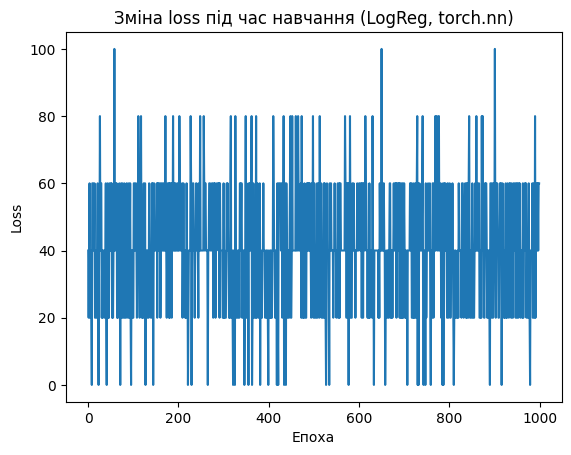


Фінальні ймовірності:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Фінальні передбачені класи:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Справжні мітки (targets):
tensor([0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 0., 1., 1., 0., 1.])


In [40]:
import matplotlib.pyplot as plt

# 11. Функція тренування моделі
def fit(num_epochs, model, loss_fn, opt, train_dl):
    losses = []

    for epoch in range(num_epochs):
        for xb, yb in train_dl:
            # 1) Прямий прохід
            preds = model(xb)

            # 2) Втрати
            loss = loss_fn(preds, yb)

            # 3) Зворотне поширення
            loss.backward()

            # 4) Оновлення параметрів
            opt.step()
            opt.zero_grad()

        losses.append(loss.item())
        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1}: loss = {loss.item():.4f}")

    return losses

# Визначаємо функцію втрат та навчаємо модель
loss_fn = F.binary_cross_entropy
num_epochs = 1000

losses = fit(num_epochs, model, loss_fn, opt, train_dl)

# Графік зміни втрат
plt.plot(losses)
plt.xlabel("Епоха")
plt.ylabel("Loss")
plt.title("Зміна loss під час навчання (LogReg, torch.nn)")
plt.show()

# Фінальні передбачення на всіх даних
with torch.no_grad():
    final_probs = model(inputs_t)
    final_preds = (final_probs >= 0.5).float()

print("\nФінальні ймовірності:")
print(final_probs.squeeze())

print("\nФінальні передбачені класи:")
print(final_preds.squeeze())

print("\nСправжні мітки (targets):")
print(targets_t.squeeze())


Після навчання моделі з використанням torch.nn.Linear та nn.Sigmoid функція втрат помітно зменшується протягом 1000 епох.
Фінальні передбачені класи збігаються зі справжніми мітками (або майже збігаються), отже модель на базі torch.nn відтворює результат ручної реалізації логістичної регресії із Секції 1.